### データフレームの作成と保存
一般的な方法
1. 外部データソースからデータフレームを作成する:
    - Pandas は CSV、Excel、SQL データベースなど様々な外部データソースから直接データフレームを作成する機能を提供しています。
2. 辞書からデータフレームを作成する:
    - キーが列名、値がデータのリストまたは配列となる辞書を使って、データフレームを作成します。
3. リストのリストからデータフレームを作成する:
    - 内側のリストが行を表し、各リストが同じ長さである必要があります。列名は別途指定することができます。

In [ ]:
# カラム名をキー、データ列を値とした辞書より、DataFrameを作成

import pandas as pd

data = {
    '名前': ['相葉雅紀', '松本潤', '二宮和也', '大野智', '櫻井翔'],
    '出身': ['千葉', '東京', '東京', '東京', '東京'],
    '生年': [1982, 1983, 1983, 1980, 1982],
    '身長': [175, 172, 168, 166, 171],
    '血液型': ['AB', 'A', 'A', 'A', 'A'],
}
df = pd.DataFrame(data)



df.head() # 最初の5行を表示


,名前,出身,生年,身長,血液型
0,相葉雅紀,千葉,1982,175,AB
1,松本潤,東京,1983,172,A
2,二宮和也,東京,1983,168,A
3,大野智,東京,1980,166,A
4,櫻井翔,東京,1982,171,A


In [ ]:
# 列名のリストと、データ列のリストを用いて、DataFrameを作成

import pandas as pd

columns = ['名前', '出身', '生年', '身長', '血液型']
data = [
    ['相葉雅紀', '千葉', 1982, 175, 'AB'],
    ['松本潤', '東京都', 1983, 172, 'A'],
    ['二宮和也', '東京都', 1983, 168, 'A'],
    ['大野智', '東京都', 1980, 166, 'A'],
    ['櫻井翔', '東京都', 1982, 171, 'A'],
]
df = pd.DataFrame(data, columns=columns)

# 保存 csv
df.to_csv('./data/arashi.csv', index=False, encoding='utf_8_sig')

# 保存 excel
# df.to_excel('./data/arashi.xlsx')


In [34]:
import pandas as pd
df2 = pd.DataFrame({
    '名前': ['大野智', '相葉雅紀', '二宮和也', '松本潤', 'カビゴン'],
    '身長': [166, 176, 168, 173, 210],
    '体重': [52.0, 58.0, 52.0, 62.0, 460.0],
})

# 保存 csv
df2.to_csv('./data/arashi2.csv', index=False, encoding='utf_8_sig')

In [ ]:
# カラム列からデータ列を取り出す

import pandas as pd

columns = ['名前', '出身', '生年', '身長', '血液型']
data = [
    ['相葉雅紀', '千葉', 1982, 175, 'AB'],
    ['松本潤', '東京都', 1983, 172, 'A'],
    ['二宮和也', '東京都', 1983, 168, 'A'],
    ['大野智', '東京都', 1980, 166, 'A'],
    ['櫻井翔', '東京都', 1982, 171, 'A'],
]
df = pd.DataFrame(data, columns=columns)

# '名前'列のデータを取り出す
for name in df['名前']:
    print(name)

# '名前'列と'血液型'列のデータを同時に取り出す
for name, blood in zip(df['名前'], df['血液型']):
    print(name, blood)


相葉雅紀
松本潤
二宮和也
大野智
櫻井翔
相葉雅紀 AB
松本潤 A
二宮和也 A
大野智 A
櫻井翔 A


In [9]:
# データ列の追加

import pandas as pd

columns = ['名前', '出身', '生年', '身長', '血液型']
data = [
    ['相葉雅紀', '千葉', 1982, 175, 'AB'],
    ['松本潤', '東京都', 1983, 172, 'A'],
    ['二宮和也', '東京都', 1983, 168, 'A'],
    ['大野智', '東京都', 1980, 166, 'A'],
    ['櫻井翔', '東京都', 1982, 171, 'A'],
]
df = pd.DataFrame(data, columns=columns)

df['性別'] = ['男性', '男性', '男性', '男性', '男性']

df['年齢'] = 2022 - df['生年']

df.head() # 最初の5行を表示


,名前,出身,生年,身長,血液型,性別,年齢
0,相葉雅紀,千葉,1982,175,AB,男性,40
1,松本潤,東京都,1983,172,A,男性,39
2,二宮和也,東京都,1983,168,A,男性,39
3,大野智,東京都,1980,166,A,男性,42
4,櫻井翔,東京都,1982,171,A,男性,40


In [18]:
# n行目のデータを取り出す

import pandas as pd

columns = ['名前', '出身', '生年', '身長', '血液型']
data = [
    ['相葉雅紀', '千葉', 1982, 175, 'AB'],
    ['松本潤', '東京都', 1983, 172, 'A'],
    ['二宮和也', '東京都', 1983, 168, 'A'],
    ['大野智', '東京都', 1980, 166, 'A'],
    ['櫻井翔', '東京都', 1982, 171, 'A'],
]
df = pd.DataFrame(data, columns=columns)

print(df.iloc[0]) # 1行目のデータを取り出す
print()

print(df['出身'][0]) # '出身'列の1行目のデータを取り出す
print(df.iloc[0]['出身']) # '出身'列の1行目のデータを取り出す



名前     相葉雅紀
出身       千葉
生年     1982
身長      175
血液型      AB
Name: 0, dtype: object

千葉
千葉


### SQL風の操作
Pandas は、SQLスタイルのデータ操作を提供している。

In [20]:
# 射影 (PROJECTION)
# SQLのSELECT文に相当する操作

import pandas as pd

# csvファイルからDataFrameを作成
df = pd.read_csv('./data/arashi.csv')


df[['名前', '血液型']] # '名前'列と'血液型'列のデータを取り出す
# SELECT 名前, 血液型 FROM df


,名前,血液型
0,相葉雅紀,AB
1,松本潤,A
2,二宮和也,A
3,大野智,A
4,櫻井翔,A


In [ ]:
# 選択(selection)
# SQLのWHERE句に相当する操作

import pandas as pd

# csvファイルからDataFrameを作成
df = pd.read_csv('./data/arashi.csv')

# queryメソッドを用いて、身長が170以上のデータを取り出す
df.query('身長 >= 170')
# SELECT * FROM df WHERE 身長 >= 170

# bool indexingを用いて、身長が170以上のデータを取り出す
df[df['身長'] >= 170]


# 複数条件
# SELECT * FROM df WHERE 身長 >= 170 AND 血液型 == "A"
df.query('身長 >= 170 and 血液型 == "A"')
df[(df['身長'] >= 170) & (df['血液型'] == 'A')]


,名前,出身,生年,身長,血液型
1,松本潤,東京都,1983,172,A
4,櫻井翔,東京都,1982,171,A


In [ ]:
# グループ化と集約
# SQLのGROUP BY句に相当する操作

import pandas as pd

# csvファイルからDataFrameを作成
df = pd.read_csv('./data/arashi.csv')

for category, grouped in df.groupby('血液型'): # '血液型'列の値をカテゴリーとしてグループ化
    print(category) # カテゴリー(ここでは血液型)
    print(grouped)  # カテゴリーごとのデータフレーム

A
     名前   出身    生年   身長 血液型
1   松本潤  東京都  1983  172   A
2  二宮和也  東京都  1983  168   A
3   大野智  東京都  1980  166   A
4   櫻井翔  東京都  1982  171   A
AB
     名前  出身    生年   身長 血液型
0  相葉雅紀  千葉  1982  175  AB


In [ ]:
# グループ化と集約
# SQLのGROUP BY句に相当する操作

import pandas as pd

# csvファイルからDataFrameを作成
df = pd.read_csv('./data/arashi.csv')

# 血液型ごとに身長の要約統計量を計算する
df.groupby('血液型')['身長'].describe()

,count,mean,std,min,25%,50%,75%,max
血液型,,,,,,,,
A,4.0,169.25,2.753785,166.0,167.5,169.5,171.25,172.0
AB,1.0,175.00,NaN,175.0,175.0,175.0,175.00,175.0


TypeError: agg function failed [how->mean,dtype->object]

### バイアスが起こす問題
1. 採用アルゴリズムの偏見
2. 医療診断ツールの性別バイアスの事例
3. 信用スコアリングの性別バイアスによる偏見事例

### バイアスへの対処方法

1. バイアスの緩和
    - 特定のデータに依存することなく、多様な視点からデータを解析する方法を模索
2. 透明性の確保
    - 分析結果を報告する際には、使用したデータとその潜在的なバイアスについて透明性を持たせることが重要
3. 追加的なデータの収集
    - バイアスを緩和するために、追加的なデータを収集することが有効な場合がある
4. 論理的な検討
    - データ分析を行う際には、常に倫理的な観点を考慮し、特定の集団に対する不利益をもたらす可能性のある結果に対して注意深く検討する


### バイアスの除去
ボストン住宅価格データセットは、もともと1970年代のデータ。

現在の常識から考えると相応しくないデータが含まれている。

'黒人'などのカラムは、 バイアスのかかったデータであり、相応しいものとは言えない。

公平でないデータは、削除してから使う。


In [7]:
# バイアスのかかったデータを削除

import pandas as pd

df = pd.read_csv('./data/boston.csv')

df.drop('黒人',axis=1,inplace=True) # '黒人'列を削除

df.head() # 最初の5行を表示


,犯罪率,緑地,工場,川近,大気汚染,部屋数,築年,通勤,交通,資産税,教員比,低所得率,住宅価格
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


### 要約統計量
要約統計量は、データセットの特性を簡潔に表現するための数値や指標のこと。

これには平均値、中央値、モード（最頻値）、標準偏差、分散、最小値、最大値、四分位数などが含まれる。


- データの理解: 要約統計量を使用することで、大量のデータから重要な情報を抽出し、データセットの基本的な特性を迅速に理解することができます。
- データの比較: 異なるデータセットを要約統計量を通じて比較することで、データ間の違いや類似点を簡単に識別できます。
- 異常値の検出: 最小値や最大値などの統計量は、データセット内の異常値や外れ値の存在を示すことがあります。
- データ分析の基礎: 要約統計量は、データの前処理やクリーニングの過程で問題点を特定するのに役立ち、さらに詳細な分析やモデリングの前段階として使用されます。

In [ ]:
# 住宅価格の統計量を表示

import pandas as pd

df = pd.read_csv('./data/boston.csv')

df.drop('黒人',axis=1,inplace=True) # '黒人'列を削除


# df['住宅価格'].describe() # 基本統計量を表示


# 住宅価格の基本統計量を個別に表示
s = df['住宅価格']

print('count :', s.count()) # データ件数
print('mean  :', s.mean()) # 平均値
print('std   :', s.std()) # 標準偏差
print('var   :', s.var()) # 分散
print('max   :', s.max()) # 最大値
print('min   :', s.min()) # 最小値
print('median:', s.median()) # 中央値
print('mode  :', s.mode().tolist())  # 最頻値が複数ある場合に対応
print('skew  :', s.skew()) # 歪度
print('kurt  :', s.kurt()) # 尖度


count : 506
mean  : 22.532806324110677
std   : 9.197104087379818
var   : 84.58672359409856
max   : 50.0
min   : 5.0
median: 21.2
mode  : [50.0]
skew  : 1.1080984082549072
kurt  : 1.495196944165818


### 箱ひげ図（boxplot)

データの分布、中央値、四分位数（第一四分位数と第三四分位数）、外れ値を視覚的に表示するためのグラフ

**データの中心傾向、散布、外れ値に焦点を当てたい場合は箱ひげ図が有効。特に、複数のグループやカテゴリ間でのデータの比較を行う際に役立つ**

<Axes: >

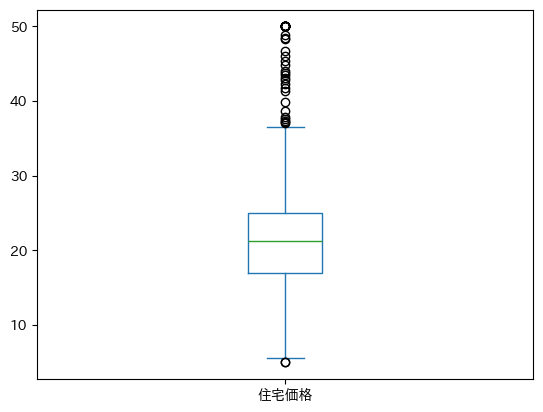

In [11]:
# 住宅価格の箱ひげ図を表示

import japanize_matplotlib # 日本語フォントを使用するためのライブラリ
import pandas as pd

df = pd.read_csv('./data/boston.csv')

df.drop('黒人',axis=1,inplace=True) # '黒人'列を削除


df[['住宅価格']].plot(kind='box')


# 四角の部分は、第一四分位数（Q1）から第三四分位数（Q3）までの範囲を示しています。
# つまり、データの中央50%がこの四角の中に含まれています。
# 四角の中の線は、データの中央値（Q2）を示しています。
# 四角の外にある点は、外れ値を示しています。外れ値は、Q1 - 1.5 * IQR より小さい値や、Q3 + 1.5 * IQR より大きい値を指します。
# ここで、IQR（Interquartile Range）は Q3 - Q1 で計算されます。
# 外れ値でない最も外側の点が ひげ となります。(ひげは、厳密には最大値、最小値を表すわけではありません。)

### ヒストグラム

データの分布を視覚化するために使用されるグラフの一種で、データセット内の値の頻度や密度を表す。

データを隣接する区間（ビンと呼ばれる）に分割し、各ビンに含まれるデータポイントの数を縦軸に、ビンの範囲を横軸に取ってプロット。

**分布形状の詳細な視覚化が必要な場合はヒストグラムが適している。データがどのように分布しているか（例：正規分布か、左右に偏っているか）**

<Axes: ylabel='Frequency'>

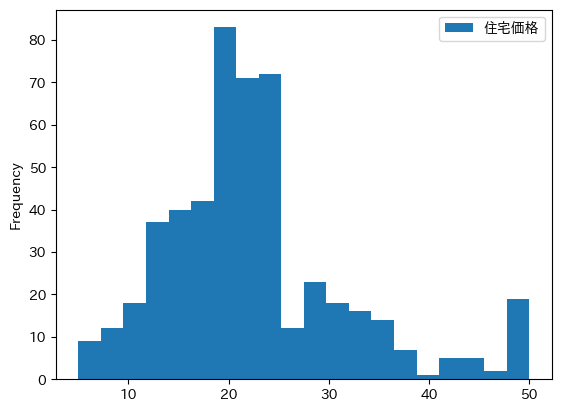

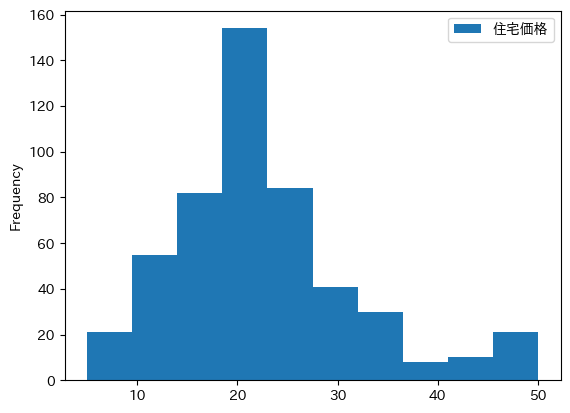

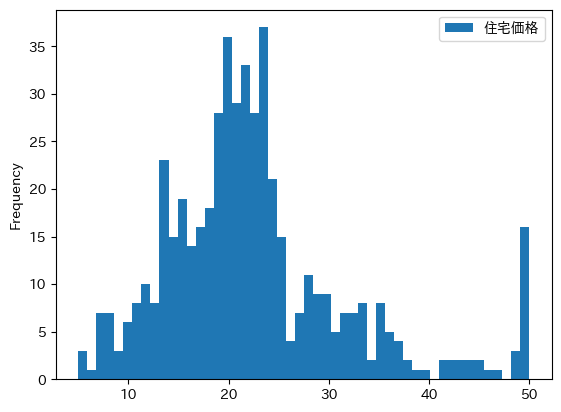

In [14]:
# 住宅価格の箱ひげ図を表示

import japanize_matplotlib # 日本語フォントを使用するためのライブラリ
import pandas as pd

df = pd.read_csv('./data/boston.csv')

df.drop('黒人',axis=1,inplace=True) # '黒人'列を削除


df[['住宅価格']].plot(kind='hist', bins=20) # ビンの数を20に設定してヒストグラムを描画

df[['住宅価格']].plot(kind='hist', bins=10) # ビンの数を10に設定してヒストグラムを描画

df[['住宅価格']].plot(kind='hist', bins=50) # ビンの数を50に設定してヒストグラムを描画

# ヒストグラムを描画する目的は、データの分布形状を把握すること
# ヒストグラムは、データの分布を視覚的に理解するための重要なツールであり、データ分析や機械学習の前処理段階でよく使用されます。
# データが正規分布しているのか、左右に偏っているのか（歪み）、あるいは複数のピークがあるのか（多峰性）など、データの全体的な傾向を把握することができます。
# ヒストグラムの見た目と解釈は、ビンのサイズ（範囲）と数に大きく依存します。
# ビンの数が少なすぎると、データの分布が過度に単純化され、重要な特徴が見逃される可能性があります。
# 一方、ビンの数が多すぎると、データの分布が過度に細分化され、ノイズが多くなり、全体的な傾向がわかりにくくなる可能性があります。
# ビンの数を適切に選択することは、データの分布を正確に理解するために重要です。


### 正規分布

- （正規分布を仮定すると） データの散らばりは、平均と標準偏差で分布を記述できます。つまり、データ値の90%は、平均値から標準偏差の範囲に分布していると見なせます。

- （正規分布から大きく外れると） 分布の非対称性や外れ値から影響を受けにくい中央値、四分位点、最大値・最小値などの値が参考になります。


**歪度(Skewness)**
- 分布の非対称性を示す指標。値が正であると分布が右に伸びている。逆に負であると左に伸びている。

**尖度(Kurtosis)**
- 正規分布を基準とした分布の鋭さの指標。基準である正規分布の尖度よりも大きければ分布は尖っており、小さければ緩やかな分布である。


#### 正規分布の近似曲線
正規分布の近似曲線を描画するためには、確率密度関数(probability density function)を使う

$$ pdf(x) = \frac{1}{\sqrt{2\pi}}e^{-\frac{x^2}{2}}  $$


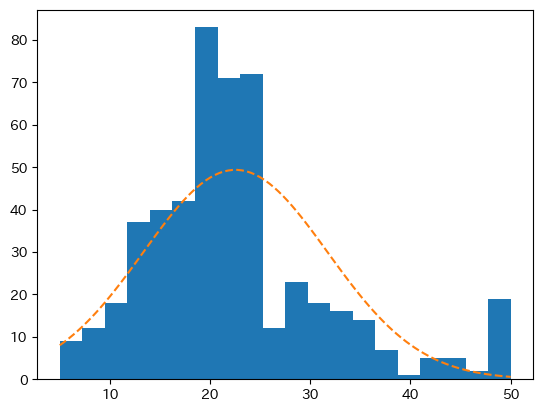

In [ ]:
# ヒストグラムと正規分布を重ねて表示

import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib # 日本語フォントを使用するためのライブラリ



from scipy.stats import norm # 正規分布を扱うためのライブラリ

x = np.linspace(-5, 5, 100)  # 区間[-5,5]を100等分する
y = norm.pdf(x)  # 確率密度関数





import pandas as pd

df = pd.read_csv('./data/boston.csv')

df.drop('黒人',axis=1,inplace=True) # '黒人'列を削除

bins = 20
k = (df['住宅価格'].max() - df['住宅価格'].min()) / bins  # 区間幅
x = np.linspace(df['住宅価格'].min(), df['住宅価格'].max(), 100) # 区間の範囲を100等分する
y = norm.pdf(x, df['住宅価格'].mean(), df['住宅価格'].std())* len(df['住宅価格']) * k # 確率密度関数をスケーリング

plt.hist(df['住宅価格'], bins=bins)  # ヒストグラム
plt.plot(x, y, linestyle='--') # 確率密度関数
plt.show()


### シャピロ・ウィルク検定

シャピロ・ウィルク検定(Shapiro-Wilk test)は、「標本は正規分布に従う母集団から無作為抽出されたものである」を帰無仮説として、正規分布を判定する方法。特に、データ数が1000以下の有効。





In [23]:
# '住宅価格'列のシャピロ・ウィルク検定"

import japanize_matplotlib # 日本語フォントを使用するためのライブラリ
import pandas as pd

df = pd.read_csv('./data/boston.csv')

df.drop('黒人',axis=1,inplace=True) # '黒人'列を削除

from scipy.stats import shapiro # シャピロ・ウィルク検定を行うためのライブラリ
statistic, p_value = shapiro(df['住宅価格'])
print('Shapiro-Wilk検定の統計量:', statistic)
print('Shapiro-Wilk検定のp値:', p_value)


# p値が0.05より小さい場合、データは正規分布していないと判断されます。
if p_value < 0.05:
    print("データは正規分布していません。")
else:
    print("データは正規分布しています。")

Shapiro-Wilk検定の統計量: 0.9171758803890093
Shapiro-Wilk検定のp値: 4.941386258635722e-16
データは正規分布していません。


### 散布図
散布図は、２つのデータ列を xy座標上にプロットしたグラフです。散布図を書くと、ふたつのデータの関連性が視覚化されて見えてきます。




<Axes: xlabel='部屋数', ylabel='住宅価格'>

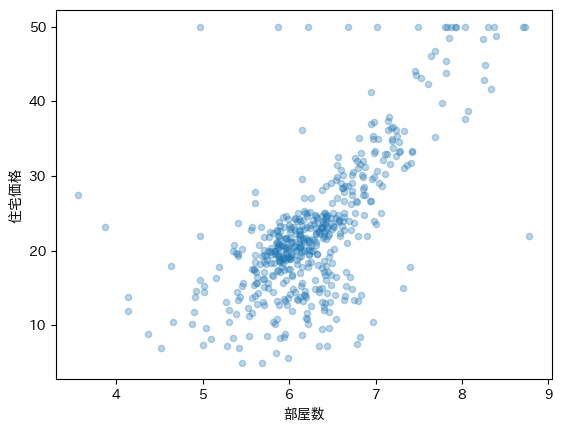

In [ ]:
# 部屋数と住宅価格の散布図を表示

import japanize_matplotlib # 日本語フォントを使用するためのライブラリ
import pandas as pd

df = pd.read_csv('./data/boston.csv')

df.drop('黒人',axis=1,inplace=True) # '黒人'列を削除

df.plot(kind='scatter', x='部屋数', y='住宅価格' ,alpha=0.5) # alphaは点の透明度を設定


# ２つの変数x,yが連動する関係のことを 相関関係という。
# 相関関係の強さを数値で表したものが 相関係数 です。



### 相関係数

散布図は、２つのデータ列の相関を分析する強力なツールになり、

この相関関係を定量化（数値化）する手法が、相関係数。

相関係数rは、2つデータ列 $ X=(x_1,x_2,...,x_n) $ , $ Y=(y_1,y_2,...,y_n) $ の関係性の強度を測る指標であり、次の式で求められる。
$$ r=\frac{\sum_{i=1}^n (x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_{i=1}^n (x_i-\bar{x})^2}\sqrt{\sum_{i=1}^n (y_i-\bar{y})^2}} $$

一般的に、
- 1に近いほど、正の相関がある(xが増加するとyも増加する傾向にある)
- 0は無総監
- -1に近いほど、負の相関がある(xが増加するとyが減少する傾向にある)

### 注意点
相関係数は、あくまでもデータ列の間にある線形な関係の尺度。因果関係を表すものではない。


### 相関関係の算出
- numpyで計算式をプログラムする
- scipiモジュールに含まれるpearsonrを用いる
- df.corr(): 数値データの全ての相関を一度に求める

In [31]:
# 部屋数と住宅価格の相関係数とp値を表示

# 部屋数と住宅価格の散布図を表示

import japanize_matplotlib # 日本語フォントを使用するためのライブラリ
import pandas as pd

df = pd.read_csv('./data/boston.csv')

df.drop('黒人',axis=1,inplace=True) # '黒人'列を削除

from scipy.stats import pearsonr # ピアソンの相関係数を計算するためのライブラリ
r, p = pearsonr(df['部屋数'], df['住宅価格'])
print('相関係数:', r)
print('p値:', p)

# p値が0.05より小さい場合、相関関係は統計的に有意であると判断されます。

# p値が0に近いほど、相関関係が強いことを示します。
# つまり、偶然に観測された相関関係が非常に起こりにくいことを意味します。
if p < 0.05:
    print("相関関係は統計的に有意です。")
else:
    print("相関関係は統計的に有意ではありません。")


相関係数: 0.6953599470715395
p値: 2.4872288710076306e-74
相関関係は統計的に有意です。


最も相関が高いペア: ('交通', '資産税', 0.9102281885331869, 4.1299201194044415e-195)
最も無相関なペア: ('川近', '交通', -0.007368240886077564, 0.8686788868076414)


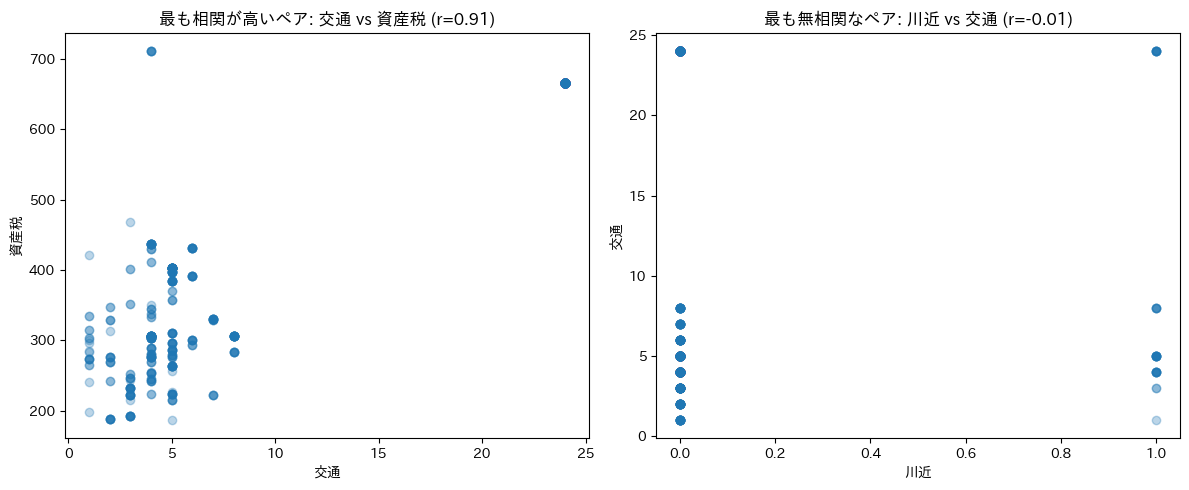

In [39]:
# 最も相関が高いものと、最も無相関なものを調べる


import japanize_matplotlib # 日本語フォントを使用するためのライブラリ
import pandas as pd

df = pd.read_csv('./data/boston.csv')

df.drop('黒人',axis=1,inplace=True) # '黒人'列を削除

from scipy.stats import pearsonr # ピアソンの相関係数を計算するためのライブラリ



# 全ての数値列のペアに対して相関係数とp値を計算
cols = df.select_dtypes(include=[float, int]).columns # 数値列の名前を取得
results = []
for i in range(len(cols)): # 各列のペアをループ
    for j in range(i+1, len(cols)): # 同じ列のペアを避けるためにjはi+1から始める
        r, p = pearsonr(df[cols[i]], df[cols[j]]) # 相関係数とp値を計算
        results.append((cols[i], cols[j], r, p)) # 結果をリストに保存

# 相関係数が最も高いペアと最も無相関なペアを見つける
most_r = max(results, key=lambda x: abs(x[2])) # 相関係数の絶対値が最も大きいペアを選ぶ
least_r = min(results, key=lambda x: abs(x[2])) # 相関係数の絶対値が最も小さいペアを選ぶ

print('最も相関が高いペア:', most_r)
print('最も無相関なペア:', least_r)

# 散布図を描画して、最も相関が高いペアと最も無相関なペアを視覚的に確認する
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df[most_r[0]], df[most_r[1]], alpha=0.3)
plt.title(f'最も相関が高いペア: {most_r[0]} vs {most_r[1]} (r={most_r[2]:.2f})')
plt.xlabel(most_r[0])
plt.ylabel(most_r[1])
plt.subplot(1, 2, 2)
plt.scatter(df[least_r[0]], df[least_r[1]], alpha=0.3)
plt.title(f'最も無相関なペア: {least_r[0]} vs {least_r[1]} (r={least_r[2]:.2f})')
plt.xlabel(least_r[0])
plt.ylabel(least_r[1])
plt.tight_layout()
plt.show()

#